# Análise Exploratória de Dados de Infraestrutura de TI

**Disciplina:** Análise Exploratória de Dados  
**Atividade:** AP1 - 15%

## Objetivo

Realizar uma análise exploratória dos dados de monitoramento de infraestrutura de TI, investigando o comportamento dos servidores a partir de métricas de latência, uso de CPU, memória e códigos de status.

A análise busca identificar padrões, possíveis valores discrepantes e relações entre as métricas, utilizando técnicas de estatística descritiva e visualização de dados.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [21]:
df = pd.read_csv("monitoramento_ti_infra.csv")

df.head()

,timestamp,server_id,metric_type,latency_ms,cpu_usage_pct,memory_usage_gb,status_code
0,2026-08-01 08:00:00,SRV-04,database,54.53,12.99,9.73,200
1,2026-08-01 08:05:00,SRV-03,api_gateway,64.58,60.05,13.60,200
2,2026-08-01 08:10:00,SRV-03,web_server,73.65,91.50,21.17,200
3,2026-08-01 08:15:00,SRV-03,api_gateway,55.97,91.89,20.52,200
4,2026-08-01 08:20:00,SRV-03,web_server,69.74,77.95,11.60,200


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        500 non-null    datetime64[us]
 1   server_id        500 non-null    str           
 2   metric_type      500 non-null    str           
 3   latency_ms       500 non-null    float64       
 4   cpu_usage_pct    500 non-null    float64       
 5   memory_usage_gb  500 non-null    float64       
 6   status_code      500 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 27.5 KB


In [39]:
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nQuantidade de linhas duplicadas:")
print(df.duplicated().sum())

Valores nulos por coluna:
timestamp          0
server_id          0
metric_type        0
latency_ms         0
cpu_usage_pct      0
memory_usage_gb    0
status_code        0
dtype: int64

Quantidade de linhas duplicadas:
0


In [40]:
print("Servidores:")
print(df["server_id"].unique())

print("\nTipos de serviço:")
print(df["metric_type"].unique())

print("\nCódigos de status:")
print(df["status_code"].unique())

print("\nValores mínimos das métricas:")
print(df[["latency_ms", "cpu_usage_pct", "memory_usage_gb"]].min())

print("\nValores máximos das métricas:")
print(df[["latency_ms", "cpu_usage_pct", "memory_usage_gb"]].max())

Servidores:
<StringArray>
['SRV-04', 'SRV-03', 'SRV-02', 'SRV-05', 'SRV-01']
Length: 5, dtype: str

Tipos de serviço:
<StringArray>
['database', 'api_gateway', 'web_server']
Length: 3, dtype: str

Códigos de status:
[200 404 500 201]

Valores mínimos das métricas:
latency_ms         0.53
cpu_usage_pct      5.06
memory_usage_gb    2.02
dtype: float64

Valores máximos das métricas:
latency_ms         90.65
cpu_usage_pct      94.88
memory_usage_gb    31.78
dtype: float64


In [41]:
print("Primeiro timestamp:")
print(df["timestamp"].iloc[0])

print("\nÚltimo timestamp:")
print(df["timestamp"].iloc[-1])

print("\nQuantidade de timestamps diferentes:")
print(df["timestamp"].nunique())

Primeiro timestamp:
2026-08-01 08:00:00

Último timestamp:
2026-08-03 01:35:00

Quantidade de timestamps diferentes:
500


In [42]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        500 non-null    datetime64[us]
 1   server_id        500 non-null    str           
 2   metric_type      500 non-null    str           
 3   latency_ms       500 non-null    float64       
 4   cpu_usage_pct    500 non-null    float64       
 5   memory_usage_gb  500 non-null    float64       
 6   status_code      500 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 27.5 KB


In [43]:
estatisticas = df[
    ["latency_ms", "cpu_usage_pct", "memory_usage_gb"]
].agg(["mean", "median", "std", "min", "max"])

estatisticas

,latency_ms,cpu_usage_pct,memory_usage_gb
mean,49.751900,49.975900,17.203480
median,50.810000,50.460000,17.060000
std,14.870005,25.151744,8.619023
min,0.530000,5.060000,2.020000
max,90.650000,94.880000,31.780000


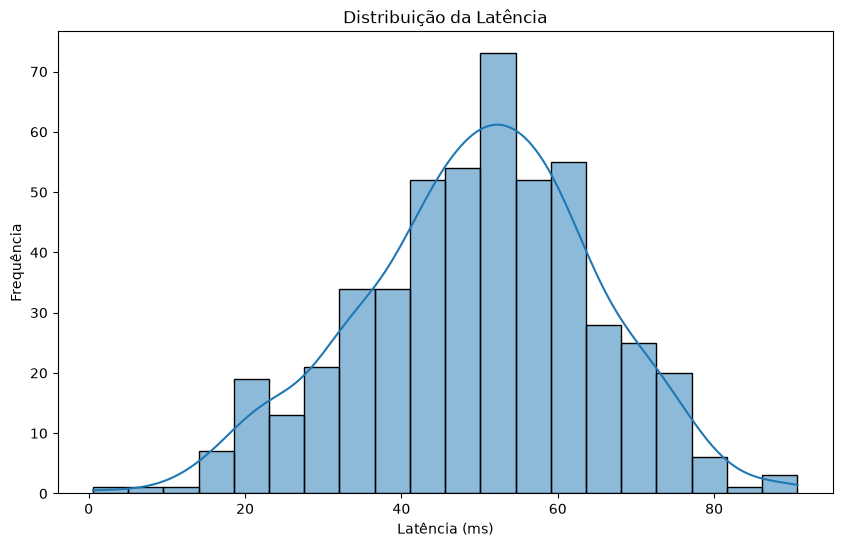

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="latency_ms", bins=20, kde=True)

plt.title("Distribuição da Latência")
plt.xlabel("Latência (ms)")
plt.ylabel("Frequência")

plt.show()

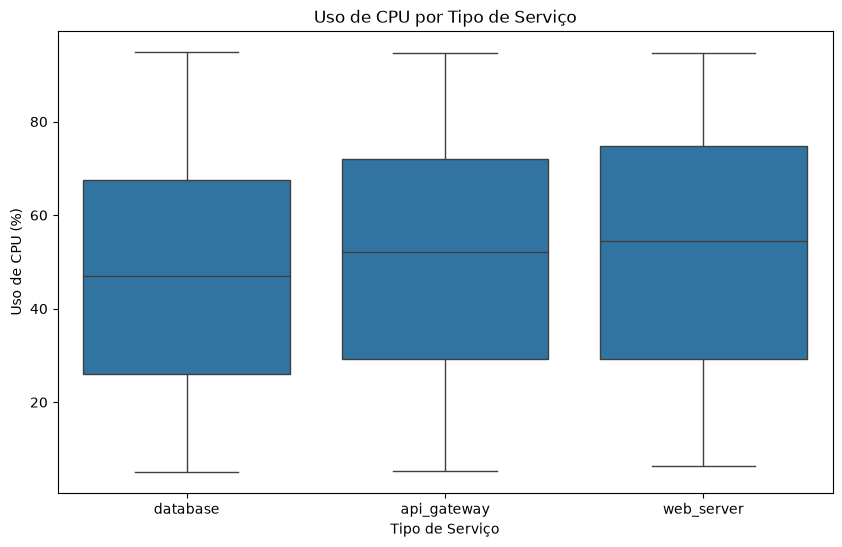

In [45]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="metric_type", y="cpu_usage_pct")

plt.title("Uso de CPU por Tipo de Serviço")
plt.xlabel("Tipo de Serviço")
plt.ylabel("Uso de CPU (%)")

plt.show()

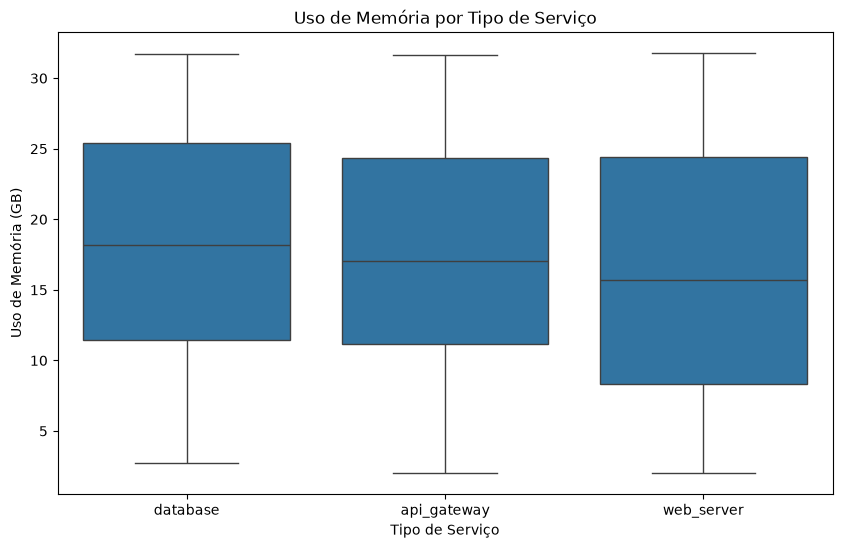

In [46]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="metric_type", y="memory_usage_gb")

plt.title("Uso de Memória por Tipo de Serviço")
plt.xlabel("Tipo de Serviço")
plt.ylabel("Uso de Memória (GB)")

plt.show()

In [47]:
correlacao = df[["cpu_usage_pct", "latency_ms"]].corr()

correlacao

,cpu_usage_pct,latency_ms
cpu_usage_pct,1.000000,-0.001624
latency_ms,-0.001624,1.000000


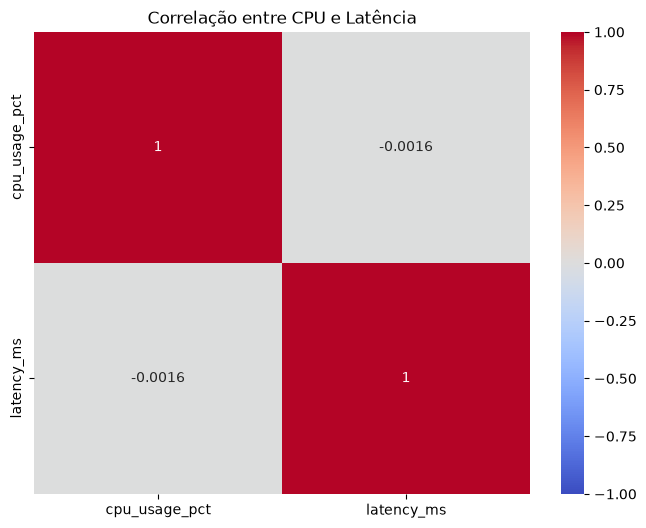

In [48]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlação entre CPU e Latência")

plt.show()

In [49]:
desempenho_servidores = df.groupby("server_id")[
    ["latency_ms", "cpu_usage_pct", "memory_usage_gb"]
].agg(["mean", "max"])

desempenho_servidores

latency_ms        cpu_usage_pct        memory_usage_gb       
                mean    max          mean    max            mean    max
server_id                                                              
SRV-01     50.807100  90.65     46.211200  92.17       18.429000  31.38
SRV-02     47.797103  75.34     50.145794  94.77       16.976822  31.78
SRV-03     49.082596  85.30     52.397212  94.88       16.955385  31.67
SRV-04     50.560745  89.18     49.919574  94.83       17.829468  31.75
SRV-05     50.775263  80.40     51.152421  94.61       15.820947  31.50

In [50]:
maiores_latencias = df.nlargest(
    10, "latency_ms"
)[
    [
        "timestamp",
        "server_id",
        "metric_type",
        "latency_ms",
        "cpu_usage_pct",
        "memory_usage_gb",
        "status_code"
    ]
]

maiores_latencias

,timestamp,server_id,metric_type,latency_ms,cpu_usage_pct,memory_usage_gb,status_code
258,2026-08-02 05:30:00,SRV-01,api_gateway,90.65,20.35,23.01,200
208,2026-08-02 01:20:00,SRV-04,database,89.18,20.00,18.63,200
272,2026-08-02 06:40:00,SRV-01,api_gateway,87.26,25.04,3.70,404
382,2026-08-02 15:50:00,SRV-03,web_server,85.30,78.28,6.04,200
12,2026-08-01 09:00:00,SRV-01,web_server,80.65,22.43,7.60,200
94,2026-08-01 15:50:00,SRV-05,web_server,80.40,48.06,7.38,200
341,2026-08-02 12:25:00,SRV-01,web_server,79.75,7.21,27.35,200
321,2026-08-02 10:45:00,SRV-01,api_gateway,79.65,72.08,12.74,200
72,2026-08-01 14:00:00,SRV-05,database,79.10,36.78,28.56,200
266,2026-08-02 06:10:00,SRV-05,api_gateway,77.38,14.76,8.20,200


In [51]:
maiores_latencias[
    [
        "timestamp",
        "server_id",
        "metric_type",
        "latency_ms",
        "cpu_usage_pct",
        "memory_usage_gb",
        "status_code"
    ]
]

,timestamp,server_id,metric_type,latency_ms,cpu_usage_pct,memory_usage_gb,status_code
258,2026-08-02 05:30:00,SRV-01,api_gateway,90.65,20.35,23.01,200
208,2026-08-02 01:20:00,SRV-04,database,89.18,20.00,18.63,200
272,2026-08-02 06:40:00,SRV-01,api_gateway,87.26,25.04,3.70,404
382,2026-08-02 15:50:00,SRV-03,web_server,85.30,78.28,6.04,200
12,2026-08-01 09:00:00,SRV-01,web_server,80.65,22.43,7.60,200
94,2026-08-01 15:50:00,SRV-05,web_server,80.40,48.06,7.38,200
341,2026-08-02 12:25:00,SRV-01,web_server,79.75,7.21,27.35,200
321,2026-08-02 10:45:00,SRV-01,api_gateway,79.65,72.08,12.74,200
72,2026-08-01 14:00:00,SRV-05,database,79.10,36.78,28.56,200
266,2026-08-02 06:10:00,SRV-05,api_gateway,77.38,14.76,8.20,200


In [52]:
maiores_latencias[
    [
        "timestamp",
        "server_id",
        "metric_type",
        "latency_ms",
        "cpu_usage_pct",
        "memory_usage_gb",
        "status_code"
    ]
].T

,258,208,272,382,12,94,341,321,72,266
timestamp,2026-08-02 05:30:00,2026-08-02 01:20:00,2026-08-02 06:40:00,2026-08-02 15:50:00,2026-08-01 09:00:00,2026-08-01 15:50:00,2026-08-02 12:25:00,2026-08-02 10:45:00,2026-08-01 14:00:00,2026-08-02 06:10:00
server_id,SRV-01,SRV-04,SRV-01,SRV-03,SRV-01,SRV-05,SRV-01,SRV-01,SRV-05,SRV-05
metric_type,api_gateway,database,api_gateway,web_server,web_server,web_server,web_server,api_gateway,database,api_gateway
latency_ms,90.65,89.18,87.26,85.3,80.65,80.4,79.75,79.65,79.1,77.38
cpu_usage_pct,20.35,20.0,25.04,78.28,22.43,48.06,7.21,72.08,36.78,14.76
memory_usage_gb,23.01,18.63,3.7,6.04,7.6,7.38,27.35,12.74,28.56,8.2
status_code,200,200,404,200,200,200,200,200,200,200


## Principais observações

A análise exploratória dos dados de infraestrutura de TI permitiu identificar o comportamento das métricas de latência, uso de CPU e memória dos servidores analisados.

- O dataset possui 500 registros e não apresenta valores nulos ou linhas duplicadas.
- A latência média foi de aproximadamente 49,72 ms, enquanto a mediana foi de 50,81 ms.
- O uso médio de CPU foi de aproximadamente 49,98%, com máximo de 94,88%.
- O uso médio de memória foi de aproximadamente 17,20 GB, com máximo de 31,78 GB.
- Os boxplots não apresentaram pontos isolados que indiquem outliers pelo critério utilizado.
- A correlação entre CPU e latência foi de aproximadamente -0,0016, indicando ausência de relação linear relevante entre essas variáveis.
- Os maiores valores de latência ocorreram em diferentes servidores e tipos de serviço, inclusive em situações de uso de CPU relativamente baixo.

## Storytelling

Durante o período analisado, os servidores apresentaram um comportamento relativamente estável nas métricas gerais, com latência média de 49,72 ms, uso médio de CPU de 49,98% e utilização média de memória de 17,20 GB. Entretanto, foram observados momentos de latência elevada, com valores chegando a 90,65 ms. O maior registro ocorreu no SRV-01, associado ao serviço `api_gateway`, enquanto outros valores elevados foram registrados em diferentes servidores e tipos de serviço. Os boxplots de CPU e memória não apresentaram pontos isolados que indicassem outliers pelo critério utilizado.

Um ponto relevante da análise foi a ausência de uma relação linear significativa entre o uso de CPU e a latência. A correlação encontrada foi de -0,0016, indicando que o aumento do uso de CPU, por si só, não explica as variações de latência observadas no conjunto de dados. Entre os maiores registros de latência, foram encontrados casos com utilização de CPU relativamente baixa, como o registro de 90,65 ms no SRV-01, que apresentou 20,35% de CPU. Isso sugere que eventuais problemas de desempenho não devem ser analisados apenas pelo consumo de CPU, sendo necessário considerar também outros fatores da infraestrutura e dos serviços.

Do ponto de vista operacional, os registros de latência elevada indicam momentos que poderiam afetar a experiência dos usuários ou o tempo de resposta das aplicações. Como esses eventos ocorreram em diferentes servidores e serviços, uma investigação mais detalhada poderia considerar individualmente cada componente da infraestrutura, além de outras métricas e informações de contexto. Dessa forma, o monitoramento contínuo pode ajudar a identificar as causas dos picos de latência e apoiar decisões relacionadas à manutenção e ao desempenho dos serviços.